In [2]:
# imports
import torch
import shutil
import numpy as np
from torch import nn
from pathlib import Path
from collections import OrderedDict
from kagglehub import dataset_download
from sklearn import linear_model, neighbors
from torchvision import transforms, datasets
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset, DataLoader, WeightedRandomSampler

C:\Users\tdows\Desktop\Machine Learning\Machine_Learning_OreoFinder\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# download dataset

local_data_path = Path("../data")
dataset_base_path = Path(dataset_download("crawford/cat-dataset"))
dataset_base_path = dataset_base_path / "cats"
oreo_path = local_data_path / "oreo"
not_oreo_path = local_data_path / "not_oreo"

oreo_path.mkdir(exist_ok=True)
not_oreo_path.mkdir(exist_ok=True)

for image in local_data_path.glob("*.jpg"):
    shutil.move(str(image), str(oreo_path / image.name))

for subdir in dataset_base_path.iterdir():
    if subdir.is_dir():
        for image in subdir.glob("*.jpg"):
            new_name = f"{subdir.name}_{image.name}"
            shutil.move(str(image), str(not_oreo_path / new_name))

In [4]:
# preprocessing

# Resize, Augment, and Normalize RGB
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2), # random brightness
    transforms.ToTensor()
])

full_dataset = datasets.ImageFolder(root=local_data_path, transform=transform)
train_loader = DataLoader(full_dataset, batch_size=32, shuffle=True)

In [5]:
# Split

targets = np.array(full_dataset.targets)
indices = np.arange(len(full_dataset))

# 80% Train
train_idx, temp_idx = train_test_split(
    indices,
    test_size=0.2,
    stratify=targets,
    random_state=42
)

# 10% validation
# 10% test
val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.5,
    stratify=targets[temp_idx],
    random_state=42
)

train_dataset = Subset(full_dataset, train_idx)
val_dataset = Subset(full_dataset, val_idx)
test_dataset = Subset(full_dataset, test_idx)

In [6]:
# Weighted Random Sampler

train_targets = targets[train_idx]
class_sample_count = np.array([len(np.where(train_targets == t)[0]) for t in np.unique(train_targets)])
weight = 1. / class_sample_count
samples_weight = np.array([weight[t] for t in train_targets])
samples_weight = torch.from_numpy(samples_weight)

sampler = WeightedRandomSampler(
    weights=samples_weight,
    num_samples=len(samples_weight),
    replacement=True
)

train_loader = DataLoader(train_dataset, batch_size=32, sampler=sampler)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

images, labels = next(iter(train_loader))
oreo_count = (labels == full_dataset.class_to_idx['oreo']).sum().item()
not_oreo_count = (labels == full_dataset.class_to_idx['not_oreo']).sum().item()

In [7]:
# logistic Regression

In [8]:
# K-NN

In [9]:
# CNN
learning_rate = 0.01
batch_size = 32
epochs = 2

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

cnn_model = nn.Sequential(
    OrderedDict([
        ("conv1", nn.Conv2d(3, 128, kernel_size=3, padding=1)),
        ("relu1", nn.ReLU()),
        ("pool1", nn.MaxPool2d(kernel_size=2, stride=2)),
        ("conv2", nn.Conv2d(128, 64, kernel_size=3, padding=1)),
        ("relu2", nn.ReLU()),
        ("pool2", nn.MaxPool2d(kernel_size=2, stride=2)),
        ("conv3", nn.Conv2d(64, 32, kernel_size=3, padding=1)),
        ("relu3", nn.ReLU()),
        ("pool3", nn.MaxPool2d(kernel_size=2, stride=2)),
        ("flatten", nn.Flatten()),
        ("linear1", nn.Linear(32 * 16 * 16, 128)),
        ("relu5", nn.ReLU()),
        ("linear2", nn.Linear(in_features=128, out_features=1)),
    ])
).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(cnn_model.parameters(), lr=learning_rate)

cnn_model.train()
for epoch in range(epochs):
    total_loss = 0

    for i, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.float().to(device)

        optimizer.zero_grad()

        output = cnn_model(images).squeeze(1)
        loss = criterion(output, labels)
        total_loss += loss.item()

        loss.backward()
        optimizer.step()

    print(f"epoch {epoch + 1}/{epochs}")
    print(f"epoch {total_loss:.2f}")

epoch 1/2
epoch 173.53
epoch 2/2
epoch 152.60


Accuracy 98.23%


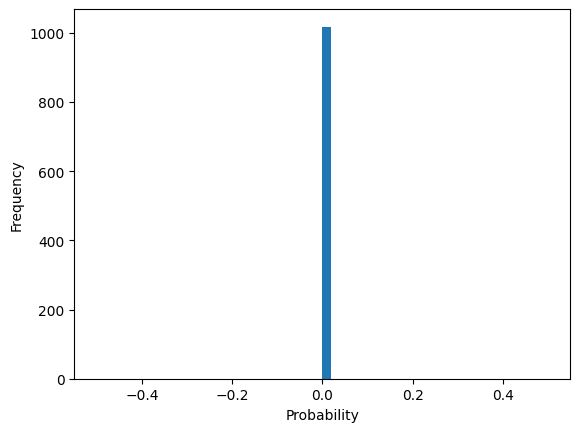

[False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False

In [17]:
# evaluation

cnn_model.eval()
all_probs = []
with torch.no_grad():
    correct, samples = 0, 0

    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.float().to(device)

        output = cnn_model(images).squeeze(1)

        predicted = (torch.sigmoid(output) > 0.9999999999999999999999999999999)
        samples += labels.size(0)
        correct += (predicted == labels).sum().item()
        all_probs.extend(predicted.tolist())

    print(f"Accuracy {(100 * correct / samples):.2f}%")

import matplotlib.pyplot as plt

plt.hist(all_probs, bins = 50)
plt.xlabel('Probability')
plt.ylabel('Frequency')
plt.show()

print(all_probs)